In [ ]:
# Import dependencies
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

# Import the data
file = Path('Capstone Data Cleaned - Sheet1.csv')
df = pd.read_csv(file, skiprows=0, header=0)

print(f"Loaded data shape: {df.shape}")

Loaded data shape: (13186, 21)


In [ ]:
print("Initial dtypes:")
print(df.dtypes)

object_cols = df.select_dtypes(include='object').columns
percentage_cols = [col for col in object_cols if col != 'W/L' and df[col].astype(str).str.contains('%', na=False).any()]

for col in percentage_cols:
    try:
        df[col] = df[col].str.replace('%', '', regex=False).astype(float) / 100
        print(f"Converted {col} to float.")
    except ValueError as e:
        print(f"Failed to convert {col}: {e}")

if 'W/L' in df.columns and df['W/L'].dtype == 'object':
    df['W/L'] = df['W/L'].str[0].map({'W': 1, 'L': 0})
    print("Mapped W/L to binary.")

print("Cleaned data head:")
print(df.head())

Initial dtypes:
W/L                   object
Team Pts               int64
Opp Pts                int64
Spread               float64
OFFENSE: Pts/Poss    float64
OFFENSE: eFG%         object
OFFENSE: TOV%         object
OFFENSE: ORB%         object
OFFENSE: FT Rate     float64
DEFENSE: Pts/Poss    float64
DEFENSE: eFG%         object
DEFENSE: TOV%         object
DEFENSE: ORB%         object
DEFENSE: FT Rate     float64
Rim                   object
Short Mid             object
Long Mid              object
All Mid               object
Corner Three          object
Non Corner            object
All Three             object
dtype: object
Converted OFFENSE: eFG% to float.
Converted OFFENSE: TOV% to float.
Converted OFFENSE: ORB% to float.
Converted DEFENSE: eFG% to float.
Converted DEFENSE: TOV% to float.
Converted DEFENSE: ORB% to float.
Converted Rim to float.
Converted Short Mid to float.
Converted Long Mid to float.
Converted All Mid to float.
Converted Corner Three to float.
Converted Non

In [ ]:
print(df.columns)
df.describe().round(2)

Index(['W/L', 'Team Pts', 'Opp Pts', 'Spread', 'OFFENSE: Pts/Poss',
       'OFFENSE: eFG%', 'OFFENSE: TOV%', 'OFFENSE: ORB%', 'OFFENSE: FT Rate',
       'DEFENSE: Pts/Poss', 'DEFENSE: eFG%', 'DEFENSE: TOV%', 'DEFENSE: ORB%',
       'DEFENSE: FT Rate', 'Rim', 'Short Mid', 'Long Mid', 'All Mid',
       'Corner Three', 'Non Corner', 'All Three'],
      dtype='object')


,W/L,Team Pts,Opp Pts,Spread,OFFENSE: Pts/Poss,OFFENSE: eFG%,OFFENSE: TOV%,OFFENSE: ORB%,OFFENSE: FT Rate,DEFENSE: Pts/Poss,...,DEFENSE: TOV%,DEFENSE: ORB%,DEFENSE: FT Rate,Rim,Short Mid,Long Mid,All Mid,Corner Three,Non Corner,All Three
count,13186.0,13186.00,13186.00,13186.00,13186.00,13186.00,13186.00,13186.00,13186.00,13186.00,...,13186.00,13186.00,13186.00,13185.00,13186.00,13135.00,13186.00,13170.00,13186.00,13186.00
mean,0.5,112.56,112.56,0.00,113.68,0.54,0.14,0.27,19.98,113.68,...,0.14,0.27,19.98,0.66,0.43,0.41,0.42,0.38,0.36,0.36
std,0.5,12.72,12.72,7.32,12.60,0.07,0.04,0.08,7.48,12.60,...,0.04,0.08,7.48,0.11,0.13,0.20,0.11,0.19,0.10,0.09
min,0.0,67.00,67.00,-23.00,68.50,0.32,0.01,-0.04,0.00,68.50,...,0.01,-0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06
25%,0.0,104.00,104.00,-5.50,105.30,0.49,0.11,0.21,14.70,105.30,...,0.11,0.21,14.70,0.59,0.33,0.29,0.35,0.25,0.29,0.31
50%,0.5,112.00,112.00,0.00,113.50,0.54,0.14,0.26,19.20,113.50,...,0.14,0.26,19.20,0.67,0.43,0.40,0.42,0.38,0.35,0.36
75%,1.0,121.00,121.00,5.50,122.00,0.59,0.16,0.32,24.70,122.00,...,0.16,0.32,24.70,0.74,0.50,0.50,0.50,0.50,0.42,0.42
max,1.0,176.00,176.00,23.00,164.60,0.83,0.30,0.56,64.70,164.60,...,0.30,0.56,64.70,1.00,1.00,1.00,0.86,1.00,0.82,0.84


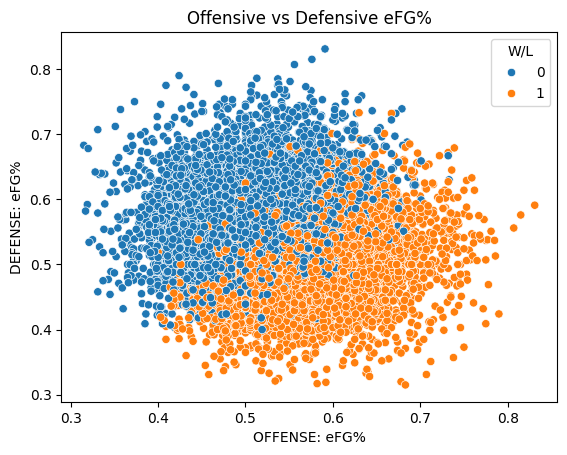

In [ ]:
graph = sns.scatterplot(data=df, x="OFFENSE: eFG%", y="DEFENSE: eFG%", hue="W/L")
graph.set_title('Offensive vs Defensive eFG%')
plt.show()

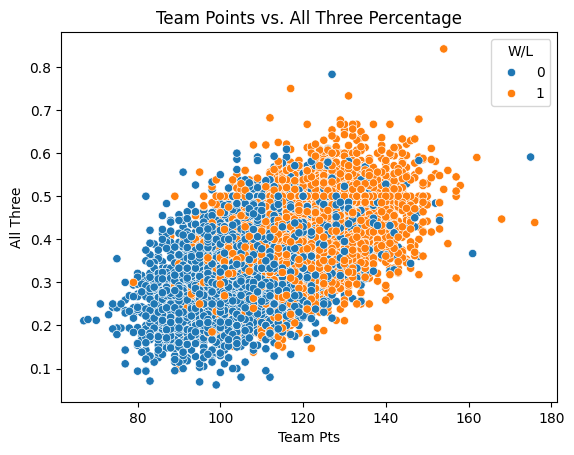

In [ ]:
graph = sns.scatterplot(data=df, x="Team Pts", y="All Three", hue="W/L")
graph.set_title('Team Points vs. All Three Percentage')
plt.show()


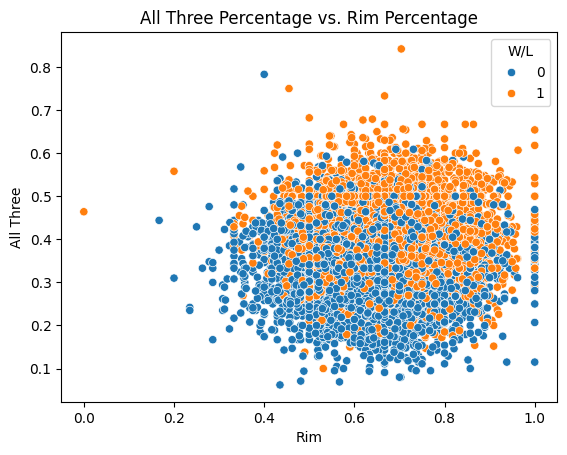

In [ ]:
graph = sns.scatterplot(data=df, x="Rim", y="All Three", hue="W/L")
graph.set_title('All Three Percentage vs. Rim Percentage')
plt.show()

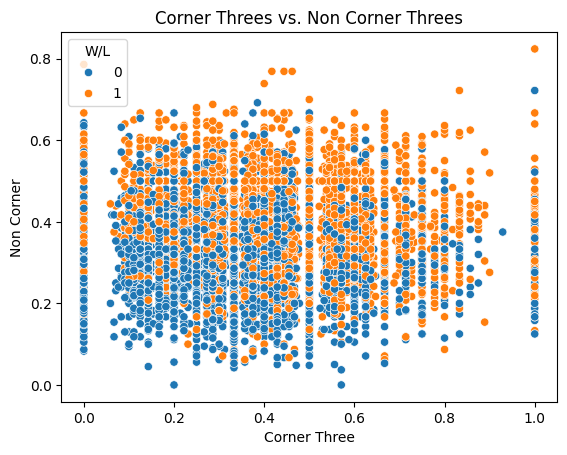

In [ ]:
graph = sns.scatterplot(data=df, x="Corner Three", y="Non Corner", hue="W/L")
graph.set_title('Corner Threes vs. Non Corner Threes')
plt.show()

In [ ]:
# Model comparison and validation using Random Forest and Logistic Regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Define the features (excluding 'W/L', 'Spread', and point-based game totals)
feature_cols = [col for col in df.columns if col not in ['W/L', 'Spread', 'Team Pts', 'Opp Pts', 'DEFENSE: Pts/Poss', 'OFFENSE: Pts/Poss']]

# Prepare data (no scaling needed for trees, but logistic benefits from standardization)
X = df[feature_cols].fillna(df[feature_cols].mean())
y = df['W/L']

# Train/test split for final evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_test_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest test accuracy: {rf_test_acc:.4f}")
print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print(f"Random Forest 5-fold CV accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

# Logistic Regression baseline
lr_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, solver='liblinear', random_state=42))
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
lr_test_acc = accuracy_score(y_test, y_pred_lr)
print(f"\nLogistic Regression test accuracy: {lr_test_acc:.4f}")
print("Logistic Regression classification report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

lr_cv = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')
print(f"Logistic Regression 5-fold CV accuracy: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")

# Feature importance summaries
rf_importances = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': rf_importances}).sort_values('Importance', ascending=False)

lr_coefs = lr_model.named_steps['logisticregression'].coef_[0]
lr_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_coefs,
    'AbsCoefficient': abs(lr_coefs)
}).sort_values('AbsCoefficient', ascending=False)

print("\nRandom Forest Feature Importances:")
print(rf_importance_df)

print("\nLogistic Regression Coefficients (absolute importance ranking):")
print(lr_importance_df[['Feature', 'Coefficient', 'AbsCoefficient']])

Random Forest test accuracy: 0.8920
Random Forest classification report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1319
           1       0.89      0.90      0.89      1319

    accuracy                           0.89      2638
   macro avg       0.89      0.89      0.89      2638
weighted avg       0.89      0.89      0.89      2638

Random Forest 5-fold CV accuracy: 0.8960 ± 0.0028

Logistic Regression test accuracy: 0.9606
Logistic Regression classification report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1319
           1       0.97      0.95      0.96      1319

    accuracy                           0.96      2638
   macro avg       0.96      0.96      0.96      2638
weighted avg       0.96      0.96      0.96      2638

Logistic Regression 5-fold CV accuracy: 0.9616 ± 0.0039

Random Forest Feature Importances:
             Feature  Importance
4      DEFEN